# Histopathologic Cancer Detection Deep Model — V7b

<center>
    <h3>Utilizing deep learning to detect cancer in histopathologic images.</h3><br>
    <h5>By: Michael Hansen</h5>
    <h5>Date: 02/04/2025 (V7b revision: 05/28/2026)</h5>
    <h5>Course: DTSA5511 Deep Learning</h5>
    <h5>Instructor: Dr. Ying Sun</h5>
    <h5> Version: V7b </h5>
</center>

This notebook is an exploration into Deep Learning and its use to detect cancer in histopathologic images. The dataset provided in this Kaggle competition is a collection of histopathologic images of breast cancer tumors. The goal is to build a model that can accurately detect cancer in these images.

The importance of being able to perform this task with a deep learning model cannot be understated. For this project I use the [Keras](https://keras.io/) library to build the model, with pooling, dropout, batch normalization and L2 regularization to improve generalization.

The dataset can be found [here](https://www.kaggle.com/competitions/histopathologic-cancer-detection/data), and was originally obtained from the [TCGA](https://portal.gdc.cancer.gov/projects/TCGA-BRCA) project. There are roughly 220,000 labeled images for training and about 57,000 for the test set.

**About this revision (V7b).**

- Update the early stopping and checkpointing to both use val_auc and not log val_auc until compile
- constant LR of 1e-4


In [1]:
import os, sys, site
from pathlib import Path
print("python:", sys.executable)
print("prefix:", sys.prefix)
def all_site_roots():
    roots = []
    for fn in (site.getsitepackages, getattr(site, "getusersitepackages", None)):
        if fn is None:
            continue
        try:
            p = fn()
        except Exception:
            continue
        if isinstance(p, (list, tuple)):
            roots.extend(p)
        elif isinstance(p, str):
            roots.append(p)
    sp = Path(sys.prefix) / "lib" / f"python{sys.version_info.major}.{sys.version_info.minor}" / "site-packages"
    if sp.is_dir():
        roots.append(str(sp))
    return list(dict.fromkeys(roots))
def nvidia_ld_paths():
    for sp in all_site_roots():
        root = Path(sp) / "nvidia"
        if not root.is_dir():
            continue
        for lib in root.rglob("lib"):
            if lib.is_dir() and any(lib.glob("*.so*")):
                yield str(lib)
extra = list(dict.fromkeys(nvidia_ld_paths()))
print("nvidia lib dirs found:", len(extra))
if not extra:
    print("No .../site-packages/nvidia/*/lib under this interpreter — TF GPU wheels are missing or wrong env.")
extra.append("/usr/lib/wsl/lib")
os.environ["LD_LIBRARY_PATH"] = ":".join(extra) + ":" + os.environ.get("LD_LIBRARY_PATH", "")
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices("GPU"))


python: /home/elgarath/tf-gpu/bin/python3
prefix: /home/elgarath/tf-gpu
nvidia lib dirs found: 11


I0000 00:00:1780090400.242570   29221 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780090400.278420   29221 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780090401.975826   29221 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Setup

In [2]:
# Importing Libraries
import os
import site
from pathlib import Path
import gc
import random
import multiprocessing
from glob import glob
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, BatchNormalization, Activation,
    Conv2D, MaxPool2D, Input, Cropping2D,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, TensorBoard, CSVLogger,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
)

from training_performance import (
    TrainingPerformanceCallback,
    default_performance_csv_path,
    sync_epochs_from_history,
    write_training_summary,
)

In [3]:
def nvidia_ld_paths():
    for sp in site.getsitepackages():
        root = Path(sp) / "nvidia"
        if not root.is_dir():
            continue
        for lib in root.rglob("lib"):
            if lib.is_dir() and any(lib.glob("*.so*")):
                yield str(lib)
extra = list(dict.fromkeys(nvidia_ld_paths()))
extra.append("/usr/lib/wsl/lib")
os.environ["LD_LIBRARY_PATH"] = ":".join(extra) + ":" + os.environ.get("LD_LIBRARY_PATH", "")
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Reproducibility: seed Python, NumPy and TensorFlow globally.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version :', tf.__version__)
print('GPUs available     :', len(tf.config.list_physical_devices('GPU')))
print('GPU devices        :', tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.21.0
GPUs available     : 1
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# Image folders: default Kaggle unzip layout (`train/`, `test/`) next to
# this notebook. CSVs live under `Data/`.
DATA_DIR = 'Data'
train_path = 'Data/train'
test_path = 'Data/test'

labels = pd.read_csv(os.path.join(DATA_DIR, 'train_labels.csv'))
print('Example of labels')
labels.head()

Example of labels


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [6]:
# Build the training dataframe by joining file paths with labels.
train_data_frame = pd.DataFrame({
    'path': [p.replace('\\', '/') for p in glob(os.path.join(train_path, '*.tif'))]
})
train_data_frame['id'] = train_data_frame.path.map(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)
df_data = train_data_frame.merge(labels, on='id')
print(f'Found {len(train_data_frame)} training images')
df_data.head()

Found 220025 training images


,path,id,label
0,Data/train/00001b2b5609af42ab0ab276dd4cd41c3e7...,00001b2b5609af42ab0ab276dd4cd41c3e7745b5,1
1,Data/train/000020de2aa6193f4c160e398a8edea95b1...,000020de2aa6193f4c160e398a8edea95b1da598,0
2,Data/train/00004aab08381d25d315384d646f5ce413e...,00004aab08381d25d315384d646f5ce413ea24b1,0
3,Data/train/0000d563d5cfafc4e68acb7c9829258a298...,0000d563d5cfafc4e68acb7c9829258a298d9b6a,0
4,Data/train/0000da768d06b879e5754c43e2298ce4872...,0000da768d06b879e5754c43e2298ce48726f722,1


In [7]:
test_data_frame = pd.DataFrame({
    'path': [p.replace('\\', '/') for p in glob(os.path.join(test_path, '*.tif'))]
})
test_data_frame['id'] = test_data_frame.path.map(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)
print(f'Found {len(test_data_frame)} test images')
test_data_frame.head()

Found 57458 test images


,path,id
0,Data/test/00006537328c33e284c973d7b39d340809f7...,00006537328c33e284c973d7b39d340809f7271b
1,Data/test/0000ec92553fda4ce39889f9226ace43cae3...,0000ec92553fda4ce39889f9226ace43cae3364e
2,Data/test/00024a6dee61f12f7856b0fc6be20bc7a48b...,00024a6dee61f12f7856b0fc6be20bc7a48ba3d2
3,Data/test/000253dfaa0be9d0d100283b22284ab2f6b6...,000253dfaa0be9d0d100283b22284ab2f6b643f6
4,Data/test/000270442cc15af719583a8172c87cd2bd9c...,000270442cc15af719583a8172c87cd2bd9c7746


## 2. Exploratory Data Analysis

Before training we want to (a) sanity-check the data we just loaded, (b) look at a few patches and the class balance, and (c) see whether there is any obviously different pixel-intensity signature between positive and negative patches.

According to the [NCBI Bookshelf entry on cancer cell morphology](https://www.ncbi.nlm.nih.gov/books/NBK9553/), cancerous cells tend to differ from healthy cells in size, shape, and color. Pairwise image comparison is infeasible at this scale, but the per-channel pixel distributions (red/green/blue + combined) give us a cheap first look.

In [8]:
def load_sample_images(data_frame, num_samples=12, seed=SEED):
    """Load a few images as RGB uint8 arrays for visualization."""
    sample_df = data_frame.sample(n=num_samples, random_state=seed)
    images, labels_out = [], []
    for _, row in sample_df.iterrows():
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
        labels_out.append(row['label'])
    return np.array(images), np.array(labels_out)

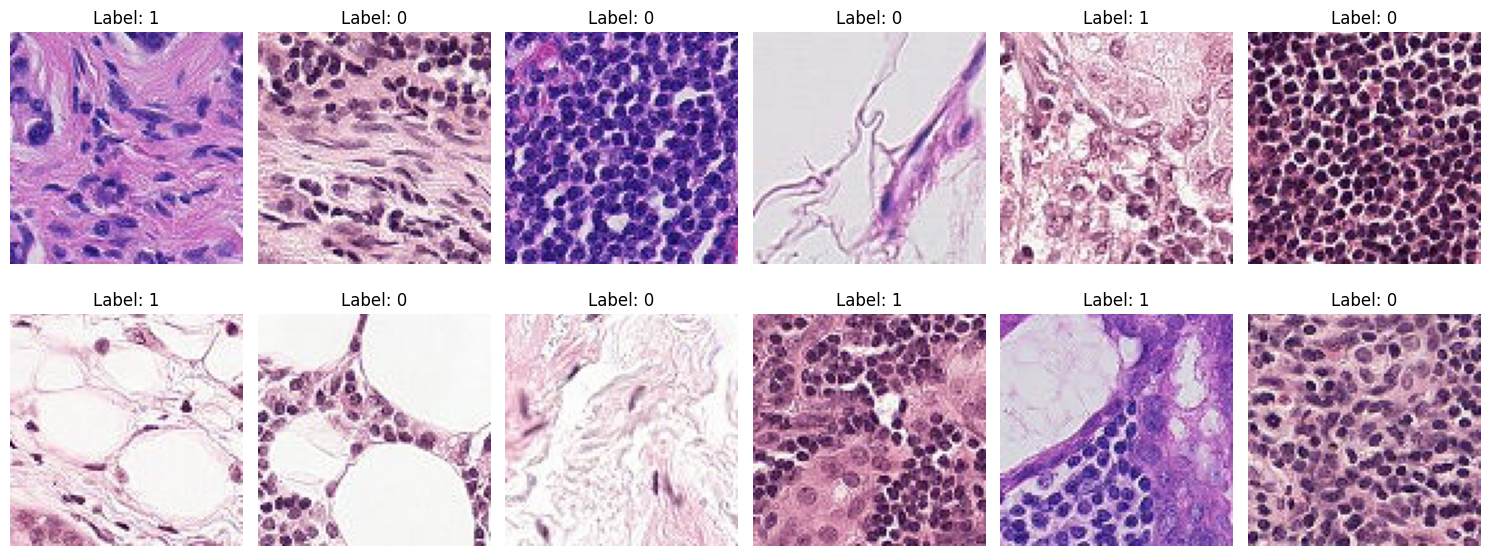


Label distribution in displayed samples:
  Label 0: 7 images
  Label 1: 5 images

Total dataset label distribution:
  Label 0: 130908 images (59.5%)
  Label 1: 89117 images (40.5%)


In [9]:
X_samples, y_samples = load_sample_images(df_data, num_samples=12)

plt.figure(figsize=(15, 6))
for plot_nr in range(len(X_samples)):
    plt.subplot(2, len(X_samples) // 2, plot_nr + 1)
    plt.imshow(X_samples[plot_nr])
    plt.title(f'Label: {y_samples[plot_nr]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

print('\nLabel distribution in displayed samples:')
unique, counts = np.unique(y_samples, return_counts=True)
for label, count in zip(unique, counts):
    print(f'  Label {label}: {count} images')

print('\nTotal dataset label distribution:')
label_counts = df_data['label'].value_counts().sort_index()
for label, count in label_counts.items():
    print(f'  Label {label}: {count} images ({count / len(df_data) * 100:.1f}%)')

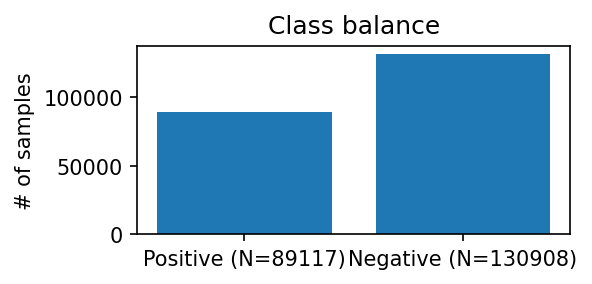

In [10]:
# Class balance plot
n_neg = int((df_data['label'] == 0).sum())
n_pos = int((df_data['label'] == 1).sum())

plt.figure(figsize=(4, 2), dpi=150)
plt.bar([1, 0], [n_neg, n_pos])
plt.xticks([1, 0], [f'Negative (N={n_neg})', f'Positive (N={n_pos})'])
plt.ylabel('# of samples')
plt.title('Class balance')
plt.tight_layout()
plt.show()

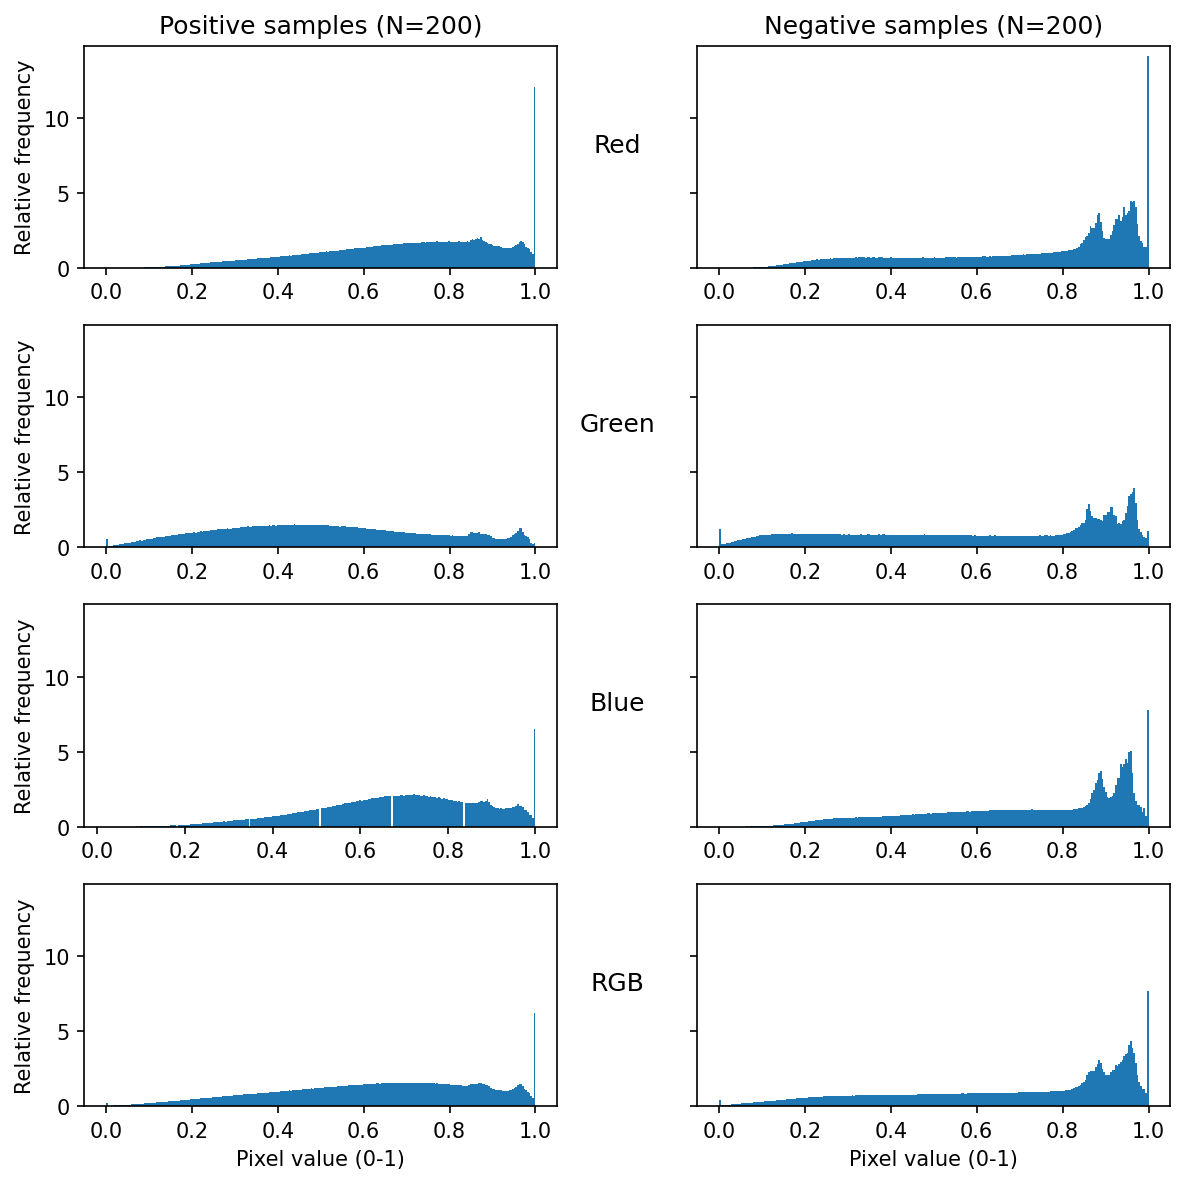

40

In [11]:
def load_batch_images(dataframe, batch_size=200, seed=SEED):
    """Load a random sample of images as RGB float arrays in [0, 1].

    Matches the training preprocessing (BGR->RGB, divide by 255) so the
    histograms below reflect what the model actually sees.
    """
    sample = dataframe.sample(n=min(batch_size, len(dataframe)), random_state=seed)
    images = []
    for _, row in sample.iterrows():
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype('float32') / 255.0
        images.append(img)
    return np.array(images)

positive_samples = df_data[df_data['label'] == 1]
negative_samples = df_data[df_data['label'] == 0]
pos_images = load_batch_images(positive_samples, batch_size=200)
neg_images = load_batch_images(negative_samples, batch_size=200)

nr_of_bins = 256
fig, axs = plt.subplots(4, 2, sharey=True, figsize=(8, 8), dpi=150)

# RGB channels
axs[0, 0].hist(pos_images[:, :, :, 0].flatten(), bins=nr_of_bins, density=True)
axs[0, 1].hist(neg_images[:, :, :, 0].flatten(), bins=nr_of_bins, density=True)
axs[1, 0].hist(pos_images[:, :, :, 1].flatten(), bins=nr_of_bins, density=True)
axs[1, 1].hist(neg_images[:, :, :, 1].flatten(), bins=nr_of_bins, density=True)
axs[2, 0].hist(pos_images[:, :, :, 2].flatten(), bins=nr_of_bins, density=True)
axs[2, 1].hist(neg_images[:, :, :, 2].flatten(), bins=nr_of_bins, density=True)
axs[3, 0].hist(pos_images.flatten(),           bins=nr_of_bins, density=True)
axs[3, 1].hist(neg_images.flatten(),           bins=nr_of_bins, density=True)

axs[0, 0].set_title(f'Positive samples (N={len(pos_images)})')
axs[0, 1].set_title(f'Negative samples (N={len(neg_images)})')
for row_idx, name in enumerate(['Red', 'Green', 'Blue', 'RGB']):
    axs[row_idx, 1].set_ylabel(name, rotation='horizontal', labelpad=35, fontsize=12)
    axs[row_idx, 0].set_ylabel('Relative frequency')
axs[3, 0].set_xlabel('Pixel value (0-1)')
axs[3, 1].set_xlabel('Pixel value (0-1)')
fig.tight_layout()
plt.show()

del pos_images, neg_images
gc.collect()

## 3. Data loaders (augmentation in the model)

Histopathology patches have no preferred orientation, so flips and mild rotation/zoom are safe augmentation. In V6 those transforms are **Keras layers inside the model** (not `ImageDataGenerator`), together with `Rescaling(1/255)`. That way the saved `.keras` file always applies the same normalization at validation and on the Kaggle test set—no separate “remember to rescale” step.

In [12]:
# Generators: load/resize/batch only. No rescale or geometric aug here —
# the model's Rescaling + Random* layers handle that (train/inference parity).
datagen = ImageDataGenerator()
validation_datagen = ImageDataGenerator()

In [13]:
batch_size = 32

# `flow_from_dataframe` expects the label column to be a string for
# class_mode='binary' so it can build the class index.
df_data_str = df_data.copy()
df_data_str['label'] = df_data_str['label'].astype(str)

X_train, X_val = train_test_split(
    df_data_str,
    test_size=0.2,
    random_state=SEED,
    stratify=df_data_str['label'],
)
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)

train_generator = datagen.flow_from_dataframe(
    dataframe=X_train,
    x_col='path',
    y_col='label',
    target_size=(96, 96),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True,
    seed=SEED,
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=X_val,
    x_col='path',
    y_col='label',
    target_size=(96, 96),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False,
)

print('Class indices:', train_generator.class_indices)

Found 176020 validated image filenames belonging to 2 classes.
Found 44005 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}


batch (32, 96, 96, 3), labels (32,), pixel range [0.0, 255.0]


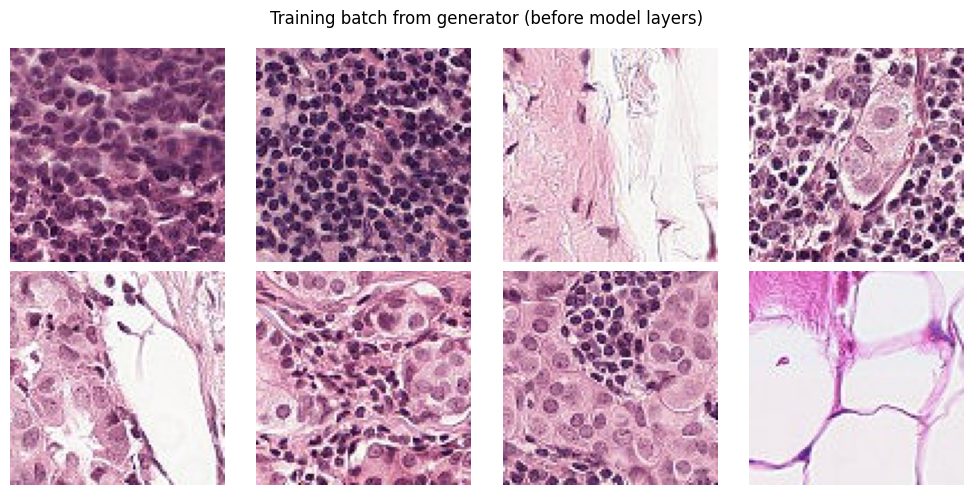

In [14]:
# Sanity check: generator should yield [0, 255] RGB (model rescales internally).
imgs, labels = next(train_generator)
print(f'batch {imgs.shape}, labels {labels.shape}, pixel range [{imgs.min():.1f}, {imgs.max():.1f}]')

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img in zip(axes.ravel(), imgs[:8]):
    display = img if img.max() <= 1.0 else (img / 255.0)
    ax.imshow(np.clip(display, 0, 1))
    ax.axis('off')
plt.suptitle('Training batch from generator (before model layers)')
plt.tight_layout()
plt.show()

## 4. Model Architecture

VGG-style stack: three convolutional blocks with increasing filter counts (32 → 64 → 128), each block being two 3×3 conv layers with batch normalization and ReLU, followed by max-pool and dropout. He initialization and L2 weight decay are applied to every conv and dense layer.

**Preprocessing head (V6):** `RandomFlip` / `RandomRotation` / `RandomZoom` plus `Rescaling(1/255)` sit before the first conv. Random layers apply only during `fit` on the training set; validation and `predict` get rescale only.

In [15]:
kernel_size = (3, 3)
pool_size = (2, 2)
first_filters = 32
second_filters = 64
third_filters = 128

dropout_conv = 0.4
dropout_dense = 0.5
l2_reg = 1e-4

def conv_bn_relu(x, filters, use_bias=False):
    x = Conv2D(
        filters,
        kernel_size,
        padding='same',
        use_bias=use_bias,
        kernel_regularizer=l2(l2_reg),
        kernel_initializer='he_normal',
    )(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')
inputs = Input(shape=(96, 96, 3))  # generator pixels in [0, 255]
x = data_augmentation(inputs)      # Random* active only when training=True
x = tf.keras.layers.Rescaling(1.0 / 255)(x)

# The label is defined by the center 32x32 region, so crop to it: 96x96 -> 32x32
x = Cropping2D(cropping=((32, 32), (32, 32)))(x)

# Conv block 1
x = conv_bn_relu(x, first_filters, use_bias=True)
x = conv_bn_relu(x, first_filters)
x = MaxPool2D(pool_size=pool_size)(x)
x = Dropout(dropout_conv)(x)

# Conv block 2
x = conv_bn_relu(x, second_filters)
x = conv_bn_relu(x, second_filters)
x = MaxPool2D(pool_size=pool_size)(x)
x = Dropout(dropout_conv)(x)

# Conv block 3
x = conv_bn_relu(x, third_filters)
x = conv_bn_relu(x, third_filters)
x = MaxPool2D(pool_size=pool_size)(x)
x = Dropout(dropout_conv)(x)

# Fully connected head
x = Flatten()(x)
x = Dense(256, use_bias=False, kernel_initializer='he_normal',
          kernel_regularizer=l2(l2_reg))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(dropout_dense)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs, name='cancer_cnn_v7b')
model.summary()

I0000 00:00:1780090563.325590   29221 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6061 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "cancer_cnn_v7b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 813,953 (3.10 MB)

 Trainable params: 812,545 (3.10 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 5. Training

We use Adam with a constant 1e-4 schedule (warm restarts let the optimizer escape shallow minima), and a small standard callbacks kit: CSV logging, and TensorBoard. Checkpoint and early stopping both use val_auc (min) so saved weights and restored weights match.



In [16]:
MODEL_VERSION = 'V7b'
PERFORMANCE_CSV = default_performance_csv_path()
EPOCHS = 15

checkpoint_path = 'model_checkpoints/best_model_v7b.keras'
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)


steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size


optimizer = Adam(learning_rate=1e-4)

performance_logger = TrainingPerformanceCallback(
    MODEL_VERSION,
    csv_path=PERFORMANCE_CSV,
)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),  # logs val_auc in fit
    ],
)
MONITOR = 'val_auc'
MODE = 'max'
early_stopping = EarlyStopping(
    monitor=MONITOR,
    mode=MODE,
    patience=5,
    restore_best_weights=True,
    verbose=2,
)
callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor=MONITOR,
        mode=MODE,
        save_best_only=True,
        verbose=2,
    ),
    early_stopping,
    performance_logger,
    CSVLogger('training_history.csv'),
    TensorBoard(log_dir='./logs', histogram_freq=1),
]


history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
)

sync_epochs_from_history(
    history.history,
    version=MODEL_VERSION,
    csv_path=PERFORMANCE_CSV,
)
np.save('training_history.npy', history.history)
print(f'Training metrics logged to {PERFORMANCE_CSV}')

Epoch 1/15


I0000 00:00:1780090565.055397   29221 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
E0000 00:00:1780090566.940495   29221 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cancer_cnn_v7b_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780090568.178344   30424 cuda_dnn.cc:461] Loaded cuDNN version 92200


5501/5501 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7331 - auc: 0.7859 - loss: 0.7136
Epoch 1: val_auc improved from None to 0.84716, saving model to model_checkpoints/best_model_v7b.keras
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 443s 80ms/step - accuracy: 0.7561 - auc: 0.8113 - loss: 0.6693 - val_accuracy: 0.5802 - val_auc: 0.8472 - val_loss: 0.8777
Epoch 2/15
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7842 - auc: 0.8462 - loss: 0.6025
Epoch 2: val_auc did not improve from 0.84716
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 434s 79ms/step - accuracy: 0.7889 - auc: 0.8502 - loss: 0.5911 - val_accuracy: 0.5371 - val_auc: 0.8395 - val_loss: 1.0249
Epoch 3/15
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7997 - auc: 0.8627 - loss: 0.5561
Epoch 3: val_auc did not improve from 0.84716
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 435s 79ms/step - accuracy: 0.8016 - auc: 0.8654 - loss: 0.5461 - val_accuracy: 0.5785 - val_auc: 0.8443 - val_loss: 1.0023
Epoch 4/15
5501/5501 ━━━━━━━━━━━━━━━━━━━━ 0s 

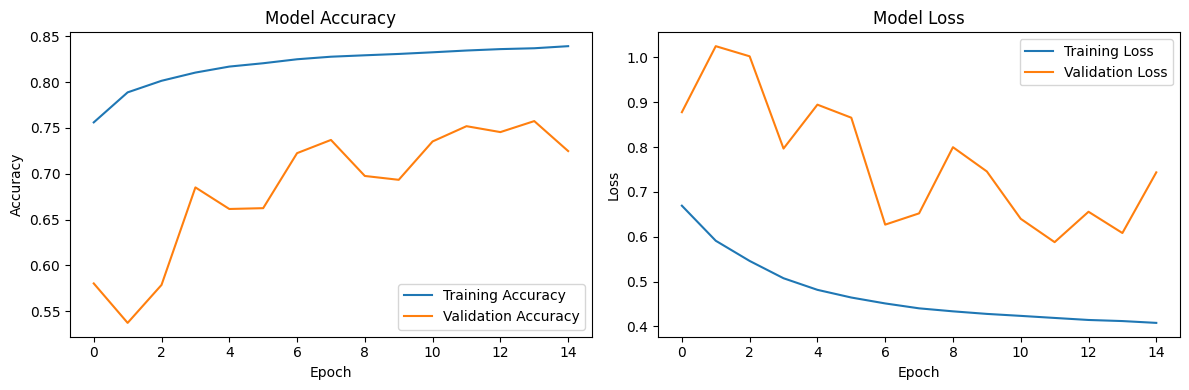

In [17]:
def plot_training_history(hist):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(hist['accuracy'], label='Training Accuracy')
    ax1.plot(hist['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(hist['loss'], label='Training Loss')
    ax2.plot(hist['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history.history)

## 6. Validation

Re-evaluate the model on the held-out validation generator and look at the full classification report, confusion matrix and ROC curve so we have more than a single accuracy number to interpret.

1376/1376 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - accuracy: 0.7520 - auc: 0.8933 - loss: 0.5880

Validation loss     : 0.5880
Validation accuracy : 0.7520
Validation AUC      : 0.8933
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 77s 56ms/step

Classification report:
              precision    recall  f1-score   support

    Negative       0.92      0.64      0.76     26182
    Positive       0.63      0.91      0.75     17823

    accuracy                           0.75     44005
   macro avg       0.78      0.78      0.75     44005
weighted avg       0.80      0.75      0.75     44005



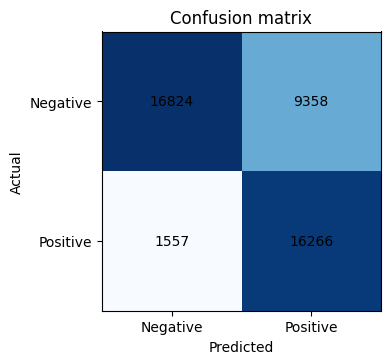


Validation ROC AUC : 0.8934


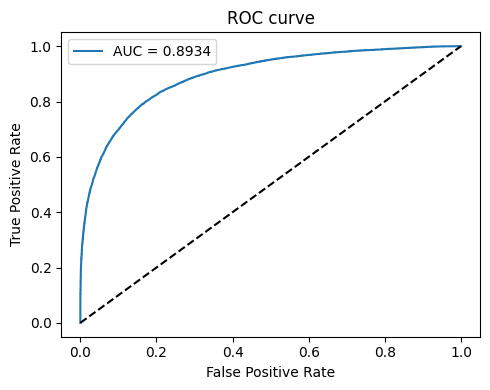

Summary row written to /mnt/c/Users/Belgarath/Desktop/DTSA5511 Deep Learning/Week 3/Histopathologic Cancer Detection Deep Model/Data/model_training_performance.csv


In [18]:
eval_results = model.evaluate(
    validation_generator, verbose=1, return_dict=True
)
val_loss = eval_results['loss']
val_accuracy = eval_results['accuracy']
val_auc_metric = eval_results.get('auc')
print(f'\nValidation loss     : {val_loss:.4f}')
print(f'Validation accuracy : {val_accuracy:.4f}')
if val_auc_metric is not None:
    print(f'Validation AUC      : {val_auc_metric:.4f}')

# Reset the generator so predictions line up with .classes ordering.
validation_generator.reset()
val_pred_prob = model.predict(
    validation_generator, verbose=1
).flatten()
val_true = validation_generator.classes[: len(val_pred_prob)]
val_pred = (val_pred_prob >= 0.5).astype(int)

report_dict = classification_report(
    val_true,
    val_pred,
    target_names=['Negative', 'Positive'],
    output_dict=True,
)
print('\nClassification report:')
print(classification_report(
    val_true, val_pred, target_names=['Negative', 'Positive']
))

# Confusion matrix
cm = confusion_matrix(val_true, val_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Negative', 'Positive'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(val_true, val_pred_prob)
roc_auc = auc(fpr, tpr)
print(f'\nValidation ROC AUC : {roc_auc:.4f}')
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()
plt.tight_layout()
plt.show()

write_training_summary(
    version=MODEL_VERSION,
    history=history.history,
    csv_path=PERFORMANCE_CSV,
    train_samples=train_generator.samples,
    val_samples=validation_generator.samples,
    batch_size=batch_size,
    epochs_planned=EPOCHS,
    eval_val_accuracy=val_accuracy,
    eval_val_loss=val_loss,
    val_roc_auc=roc_auc,
    classification_report_dict=report_dict,
    early_stopping_restored_epoch=early_stopping.best_epoch + 1,
    model_architecture='VGG-style CNN (32-64-128 filters, BN, L2, Dropout)',
    l2_reg=l2_reg,
    augmentation='Keras RandomFlip/Rotation/Zoom + Rescaling(1/255) in model',
    optimizer='Adam',
    lr_schedule='1e-4',
    dropout_conv=dropout_conv,
    dropout_dense=dropout_dense,
    checkpoint_monitor='val_auc',
    early_stopping_monitor='val_auc',
    early_stopping_patience=5,
    notebook_file='Histopathologic Cancer Detection Deep Model - V7b.ipynb',
)
print(f'Summary row written to {PERFORMANCE_CSV}')

## 7. Kaggle Submission

Generate predictions for the test set and write `Data/submission.csv`.

1. **Same preprocessing as training**: BGR→RGB, pixels in `[0, 255]` float32. The model's `Rescaling(1/255)` layer applies at `predict` time—do **not** divide by 255 in Python 
2. **Parallel I/O + atomic writes**: `ThreadPoolExecutor` reads TIFs in parallel; the CSV is rewritten after every batch so a crash does not lose progress.

In [19]:
def process_test_image(path):
    """Read a test image with the same preprocessing as training.

    Returns float32 RGB in [0, 255] (model Rescaling layer divides by 255).
    """
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype('float32')

os.makedirs(DATA_DIR, exist_ok=True)
submission_path = os.path.join(DATA_DIR, 'submission.csv')
print(submission_path)
target_size = (96, 96)
file_batch = 500
num_workers = max(1, multiprocessing.cpu_count() - 2)
max_idx = len(test_data_frame)

submission = pd.DataFrame()

for idx in tqdm(range(0, max_idx, file_batch),
                desc='Processing test batches', unit='batch'):
    batch_df = test_data_frame.iloc[idx:idx + file_batch].copy()
    paths = batch_df['path'].tolist()

    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(executor.map(process_test_image, paths))

    valid_imgs, valid_idx = [], []
    for i, img in enumerate(results):
        if img is not None and img.shape == (*target_size, 3):
            valid_imgs.append(img)
            valid_idx.append(i)
        else:
            shape = None if img is None else img.shape
            print(f'Skipping {paths[i]} (shape={shape})')

    if not valid_imgs:
        continue

    K_test = np.stack(valid_imgs)
    preds = model.predict(K_test, verbose=0).flatten()

    batch_out = batch_df.iloc[valid_idx].copy()
    batch_out['label'] = preds

    submission = pd.concat([submission, batch_out[['id', 'label']]])
    # Atomic-ish snapshot after every batch so a crash mid-loop doesn't
    # lose all of the predictions computed so far.
    submission.to_csv(submission_path, index=False, header=True)

print(f'\nWrote {len(submission)} predictions to {submission_path}')
submission.head()

Data/submission.csv


Processing test batches: 100%|██████████| 115/115 [00:55<00:00,  2.08batch/s]


Wrote 57458 predictions to Data/submission.csv


,id,label
0,00006537328c33e284c973d7b39d340809f7271b,0.948264
1,0000ec92553fda4ce39889f9226ace43cae3364e,0.983292
2,00024a6dee61f12f7856b0fc6be20bc7a48ba3d2,0.729106
3,000253dfaa0be9d0d100283b22284ab2f6b643f6,0.722596
4,000270442cc15af719583a8172c87cd2bd9c7746,0.115066
